In [18]:
# ==========================================
# CELL 1 & 2: FOURIER DDR-PINN COM BOUNDS FÍSICOS
# ==========================================
import torch
import torch.nn as nn
import deepwave
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"HPC Node Active: {device}\n")

nx, ny = 70, 70
dx = 10.0
dt = 0.004
nt = 1000
num_shots = 5

v_true = torch.full((nx, ny), 1500.0, device=device)
v_true[30:50, 20:50] = 2500.0 

source_locations = torch.zeros(num_shots, 1, 2, dtype=torch.long, device=device)
source_locations[:, 0, 0] = 0
source_locations[:, 0, 1] = torch.round(torch.linspace(10, nx - 10, num_shots)).long().to(device)

receiver_locations = torch.zeros(num_shots, nx, 2, dtype=torch.long, device=device)
receiver_locations[:, :, 0] = 0
receiver_locations[:, :, 1] = torch.arange(nx, dtype=torch.long).repeat(num_shots, 1).to(device)

class FourierVelocityNet(nn.Module):
    # CORREÇÃO 1: Fator de Escala reduzido para 2.0 (Mitiga aliasing e explosão)
    def __init__(self, mapping_size=128, scale=2.0):
        super().__init__()
        self.B = torch.randn((2, mapping_size), device=device) * scale
        
        self.net = nn.Sequential(
            nn.Linear(2 * mapping_size, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1)
        )
        
    def forward(self, x, z):
        x_norm = (x / (nx - 1.0)) * 2.0 - 1.0
        z_norm = (z / (ny - 1.0)) * 2.0 - 1.0
        coords = torch.cat([x_norm, z_norm], dim=1)
        
        proj = (2.0 * math.pi) * torch.matmul(coords, self.B)
        fourier_features = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        
        # CORREÇÃO 2: Bound físico absoluto restrito ao escopo do alvo [1500, 2500]
        return 1500.0 + 1000.0 * torch.sigmoid(self.net(fourier_features))

v_net = FourierVelocityNet().to(device)

x_grid, z_grid = torch.meshgrid(torch.arange(nx, dtype=torch.float32), 
                                torch.arange(ny, dtype=torch.float32), indexing='ij')
x_flat = x_grid.reshape(-1, 1).to(device)
z_flat = z_grid.reshape(-1, 1).to(device)

print("Fourier-PINN Neural Network Re-Initialized with strict Physical Bounds.")

HPC Node Active: cuda

Fourier-PINN Neural Network Re-Initialized with strict Physical Bounds.


In [19]:
# ==========================================
# CELL 3 & 4: MULTI-SCALE OPTIMIZATION COM TV ANNEALING
# ==========================================
import torch.nn.functional as F

frequencies = [5.0, 15.0, 25.0]
epochs_per_scale = 100
global_epoch = 0
history = {'epoch': [], 'loss': [], 'scale': []}

# CORREÇÃO ESTRUTURAL: Dicionário de TV Annealing
# 5Hz: TV ativa para formar o macro-bloco ortogonal.
# 15Hz: TV reduzida em 10x para permitir deformação física.
# 25Hz: TV desligada (0.0). Apenas a física da onda (MSE) refina as bordas.
tv_weights = {
    5.0: 1e-8,
    15.0: 1e-9,
    25.0: 0.0
}

print(f"Igniting DDR-PINN Multi-Scale Inversion with TV Annealing...")

for freq in frequencies:
    print(f"==========================================")
    print(f"   INITIATING SCALE: {freq} Hz | TV Weight: {tv_weights[freq]}")
    print(f"==========================================")
    
    current_lambda_tv = tv_weights[freq]
    optimizer = torch.optim.Adam(v_net.parameters(), lr=1e-3)
    
    source_amplitudes_scale = (
        deepwave.wavelets.ricker(freq, nt, dt, 1.5 / freq)
        .reshape(1, 1, -1).repeat(num_shots, 1, 1).to(device)
    )
    
    with torch.no_grad():
        out_true = deepwave.scalar(
            v_true, grid_spacing=dx, dt=dt,
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )
        observed_seismograms_scale = out_true[-1].clone().detach()
        
    for epoch in range(epochs_per_scale):
        optimizer.zero_grad()
        
        v_pred_flat = v_net(x_flat, z_flat)
        v_pred = v_pred_flat.reshape(nx, ny)
        
        out = deepwave.scalar(
            v_pred, grid_spacing=dx, dt=dt, 
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )
        
        # 1. Perda de Dados
        loss_data = F.mse_loss(out[-1], observed_seismograms_scale)
        
        # 2. Perda TV Dinâmica
        if current_lambda_tv > 0.0:
            tv_loss = torch.sum(torch.abs(v_pred[1:, :] - v_pred[:-1, :])) + \
                      torch.sum(torch.abs(v_pred[:, 1:] - v_pred[:, :-1]))
            loss = loss_data + (current_lambda_tv * tv_loss)
            tv_val = (current_lambda_tv * tv_loss).item()
        else:
            loss = loss_data
            tv_val = 0.0
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(v_net.parameters(), max_norm=1.0)
        optimizer.step()
        
        if epoch % 20 == 0 or epoch == epochs_per_scale - 1:
            history['epoch'].append(global_epoch)
            history['loss'].append(loss.item())
            history['scale'].append(freq)
            print(f"Scale {freq}Hz | Global Epoch {global_epoch:03d} | Total Loss: {loss.item():.6f} | TV: {tv_val:.6f}")
            
        global_epoch += 1

print("\nOptimization Complete. TV Annealing successfully prevented artifact binarization.")

Igniting DDR-PINN Multi-Scale Inversion with TV Annealing...
   INITIATING SCALE: 5.0 Hz | TV Weight: 1e-08
Scale 5.0Hz | Global Epoch 000 | Total Loss: 1.629580 | TV: 0.000496
Scale 5.0Hz | Global Epoch 020 | Total Loss: 0.052624 | TV: 0.005603
Scale 5.0Hz | Global Epoch 040 | Total Loss: 0.012133 | TV: 0.005266
Scale 5.0Hz | Global Epoch 060 | Total Loss: 0.005648 | TV: 0.003383
Scale 5.0Hz | Global Epoch 080 | Total Loss: 0.004039 | TV: 0.002757
Scale 5.0Hz | Global Epoch 099 | Total Loss: 0.003393 | TV: 0.002515
   INITIATING SCALE: 15.0 Hz | TV Weight: 1e-09
Scale 15.0Hz | Global Epoch 100 | Total Loss: 0.001827 | TV: 0.000250
Scale 15.0Hz | Global Epoch 120 | Total Loss: 0.000429 | TV: 0.000222
Scale 15.0Hz | Global Epoch 140 | Total Loss: 0.000248 | TV: 0.000195
Scale 15.0Hz | Global Epoch 160 | Total Loss: 0.000213 | TV: 0.000183
Scale 15.0Hz | Global Epoch 180 | Total Loss: 0.000200 | TV: 0.000180
Scale 15.0Hz | Global Epoch 199 | Total Loss: 0.000193 | TV: 0.000179
   INITIAT

Extracting tensors and generating Multi-Scale visual dashboard...


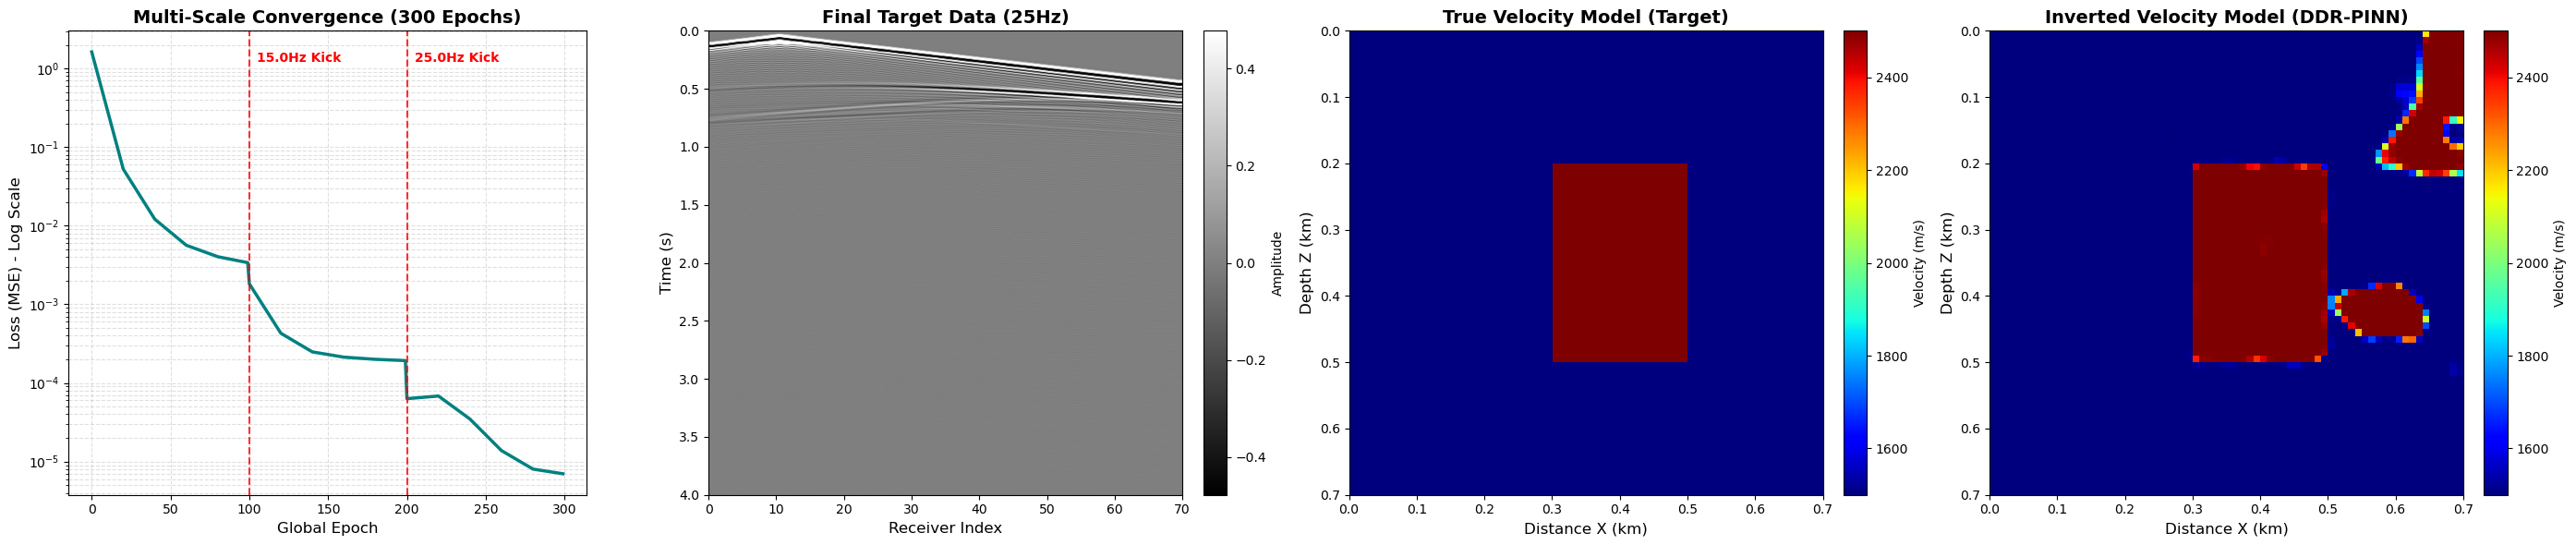

In [20]:
# ==========================================
# CELL 5: DDR-PINN VISUAL ANALYSIS DASHBOARD (MULTI-SCALE)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import torch

print("Extracting tensors and generating Multi-Scale visual dashboard...")

# 1. Query the Neural Network and Extract Ground Truth
with torch.no_grad():
    v_pred_flat = v_net(x_flat, z_flat)
    # Reshape the flat predictions back into the 2D spatial grid and transpose
    velocity_model_pred = v_pred_flat.reshape(nx, ny).cpu().numpy().T 
    
    # Extract the True Velocity Model we generated in Cell 1
    velocity_model_true = v_true.cpu().numpy().T

# CORREÇÃO 1: Extrair o sismograma da última escala processada (25Hz)
seismogram_data = observed_seismograms_scale[0].cpu().numpy() 

# 2. Establish physical spatial extents (converting meters to kilometers)
x_max = (nx * dx) / 1000.0
z_max = (ny * dx) / 1000.0 # dx is used since grid spacing is isotropic (dx=dz)

# 3. Initialize the 1x4 Figure Layout
fig, axes = plt.subplots(1, 4, figsize=(28, 6), facecolor='white')

# --- PANEL 1: Convergence Trajectory (ELEVADO COM MARCADORES MULTI-SCALE) ---
epochs_log = history['epoch']
loss_log = history['loss']
scales_log = history['scale']

axes[0].semilogy(epochs_log, loss_log, color='teal', linewidth=2.5)
# CORREÇÃO 2: Título dinâmico para refletir as épocas reais
axes[0].set_title(f'Multi-Scale Convergence ({global_epoch} Epochs)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Global Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE) - Log Scale', fontsize=12)
axes[0].grid(True, which="both", ls="--", alpha=0.4)

# INJEÇÃO ESTRATÉGICA: Marcar visualmente os "Optimizer Kicks" e saltos de frequência
for i in range(1, len(scales_log)):
    if scales_log[i] != scales_log[i-1]:
        kick_epoch = epochs_log[i]
        axes[0].axvline(x=kick_epoch, color='red', linestyle='--', alpha=0.8)
        axes[0].text(kick_epoch + 5, max(loss_log), f'{scales_log[i]}Hz Kick', color='red', fontweight='bold', verticalalignment='top')

# --- PANEL 2: Observed Seismogram (Data) ---
vmax_seismo = np.percentile(np.abs(seismogram_data), 98) 
im_seismo = axes[1].imshow(seismogram_data.T, aspect='auto', cmap='gray', 
                           extent=[0, nx, nt * dt, 0],
                           vmin=-vmax_seismo, vmax=vmax_seismo)
axes[1].set_title('Final Target Data (25Hz)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Receiver Index', fontsize=12)
axes[1].set_ylabel('Time (s)', fontsize=12)
fig.colorbar(im_seismo, ax=axes[1], fraction=0.046, pad=0.04, label='Amplitude')

# --- PANEL 3: True Velocity Model (Ground Truth) ---
im_true = axes[2].imshow(velocity_model_true, aspect='auto', cmap='jet', 
                         extent=[0, x_max, z_max, 0], vmin=1500, vmax=2500)
axes[2].set_title('True Velocity Model (Target)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Distance X (km)', fontsize=12)
axes[2].set_ylabel('Depth Z (km)', fontsize=12)
fig.colorbar(im_true, ax=axes[2], fraction=0.046, pad=0.04, label='Velocity (m/s)')

# --- PANEL 4: Inverted Velocity Model (DDR-PINN) ---
im_pred = axes[3].imshow(velocity_model_pred, aspect='auto', cmap='jet', 
                         extent=[0, x_max, z_max, 0], vmin=1500, vmax=2500)
axes[3].set_title('Inverted Velocity Model (DDR-PINN)', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Distance X (km)', fontsize=12)
axes[3].set_ylabel('Depth Z (km)', fontsize=12)
fig.colorbar(im_pred, ax=axes[3], fraction=0.046, pad=0.04, label='Velocity (m/s)')

# 4. Render and Export
plt.tight_layout()
fig.savefig('ddr_pinn_final_dashboard_multiscale.png', dpi=300, bbox_inches='tight')
plt.show()